In [80]:
# Importando bibliotecas
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split #para dividir os dados em treino e teste
from sklearn.compose import ColumnTransformer # para aplicar diferentes transformações em diferentes colunas do dataset
from sklearn.pipeline import Pipeline # para criar um pipeline de pré-processamento e modelagem
from sklearn.impute import SimpleImputer # para lidar com valores ausentes
from sklearn.preprocessing import OneHotEncoder # para codificar variáveis categóricas
from sklearn.preprocessing import StandardScaler # para padronizar os dados

**Conhecimento e Preparação dos Dados**

In [81]:
"""Leitura da base de dados, em seguida, análise exploratória dos dados"""

df = pd.read_csv(r'C:\Users\marciohenrique\Documents\Projetos\github\ml_stat\bases_dados\base_imoveis.csv')
#df.shape #para verificar o tamanho do dataset (linhas, colunas)
#df.head() #para visualizar as primeiras linhas do dataset
#df.info() # para verificar o tipo de cada coluna e a quantidade de valores não nulos
df.describe() # para verificar estatísticas da base de dados

,area_m2,quartos,banheiros,vagas_garagem,idade_anos,preco_venda
count,5216.000000,5156.000000,5182.000000,5181.000000,5180.000000,5.173000e+03
mean,294.827837,3.621412,4.149170,2.566879,20.087645,8.732209e+05
std,163.986606,1.113622,1.792976,1.071757,11.778055,7.552051e+05
min,40.000000,1.000000,1.000000,0.000000,0.000000,7.895600e+04
25%,148.000000,3.000000,3.000000,2.000000,10.000000,4.036640e+05
50%,275.000000,4.000000,4.000000,3.000000,20.000000,6.653100e+05
75%,439.000000,5.000000,5.000000,3.000000,30.000000,1.076094e+06
max,600.000000,5.000000,7.000000,4.000000,40.000000,7.373758e+06


In [82]:
"""Tabela de nulos, passo extra de qualidade de dados, pvisualizar quais são os nulos na base de dados"""
nulos = pd.DataFrame({
    "Nulos": df.isnull().sum(),
    "% Nulos":round(df.isnull().mean() * 100, 2)
})

nulos.sort_values("% Nulos", ascending=False)

,Nulos,% Nulos
quartos,344,6.25
preco_venda,327,5.95
idade_anos,320,5.82
vagas_garagem,319,5.80
banheiros,318,5.78
tipo,300,5.45
localidade,290,5.27
area_m2,284,5.16
id_imovel,0,0.00


In [83]:
"""Tratamento de valores nulos, para as colunas numéricas, 
vamos substituir os valores nulos pela mediana da coluna,
 e para as colunas categóricas, vamos substituir os valores nulos pela moda da coluna tudo via pipeline.
 exclusão de nulos da variavel alvo (preco_venda) """

colunas = [
    "area_m2",
    "quartos",
    "banheiros",
    "vagas_garagem",
    "idade_anos",
    "localidade",
    "tipo"
]

val_numer = [
    "area_m2",
    "quartos",
    "banheiros",
    "vagas_garagem",
    "idade_anos"
]

val_categ = [
    "localidade",
    "tipo"
]

df = df.dropna(subset=["preco_venda"]).copy() #copia da base de dados para não alterar a original


transf_val_num= Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")), # substitui valores nulos pela mediana
    ]
)


transf_val_cat= Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")), # substitui valores nulos pela moda
    ("onehot", OneHotEncoder(handle_unknown="ignore")) # codifica variáveis categóricas
    ]
)

In [84]:
"""Definindo as variaveis preditoras e a variável alvo
Configuração do percuntual de treino e teste, 80% para treino e 20% para teste"""
X = df[colunas]
y = df["preco_venda"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 80% treino e 20% teste

In [85]:
"""Preprocessamento dos dados, aplicando as transformações definidas anteriormente nas colunas numéricas e categóricas """
preprocessamento = ColumnTransformer(
    transformers=[
        ("num", transf_val_num, val_numer),
        ("cat", transf_val_cat, val_categ)
    ]
)

**Aplicando algoritimo de Regressão Linear**

In [86]:
# Regressão Linear
from sklearn.linear_model import LinearRegression

modelo_linear = Pipeline(steps=[                    #definindo o pipeline de regressão linear
    ("preprocessamento", preprocessamento),
    ("modelo", LinearRegression())
    ]
)

modelo_linear.fit(X_train, y_train) #treinando o modelo de regressão linear
y_pred_linear = modelo_linear.predict(X_test) #fazendo previsões com o modelo de regressão linear


**Avaliação do modelo de regressão linear**

In [87]:
from sklearn.metrics import ( mean_absolute_error, mean_squared_error, r2_score )
mae_linear = mean_absolute_error( y_test, y_pred_linear )
rmse_linear = np.sqrt( mean_squared_error( y_test, y_pred_linear ) )
r2_linear = r2_score( y_test, y_pred_linear )

print(f"R²: {r2_linear:.4f}")
print(f"MAE : R$ {mae_linear:,.2f}") 
print(f"RMSE: R$ {rmse_linear:,.2f}") 

R²: 0.8288
MAE : R$ 202,419.53
RMSE: R$ 329,888.56


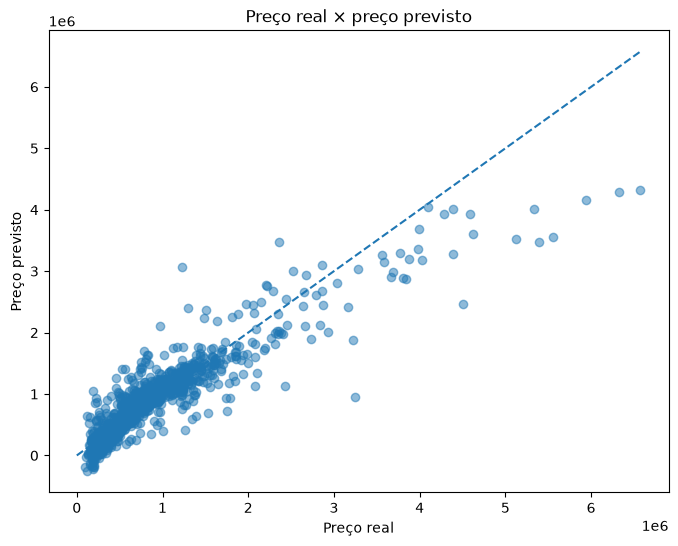

In [88]:
"""Grafico de dispersão entre o preço real e o preço previsto pelo modelo de regressão linear"""

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_linear,
    alpha=0.5
)

limite = max(y_test.max(), y_pred_linear.max())

plt.plot(
    [0, limite],
    [0, limite],
    linestyle="--"
)

plt.xlabel("Preço real")
plt.ylabel("Preço previsto")
plt.title("Preço real × preço previsto")

plt.show()


**Onde o modelo mais errou**

In [89]:
"""Tabela de diferença entre o preço real e o preço previsto pelo modelo de regressão linear"""
tabela_diferenca_linear = pd.DataFrame({
    "Real": y_test,
    "Previsto": y_pred_linear,
    "Diferença": y_test-y_pred_linear,
    "Erro bruto": abs(y_test-y_pred_linear),
})

print("10 maiores erros na RL:")
display(tabela_diferenca_linear.sort_values("Erro bruto", ascending=False).head(10))

10 maiores erros na RL:


,Real,Previsto,Diferença,Erro bruto
1882,3249378.0,9.484720e+05,2.300906e+06,2.300906e+06
4211,6575587.0,4.314294e+06,2.261293e+06,2.261293e+06
3236,6329296.0,4.289165e+06,2.040131e+06,2.040131e+06
312,4500331.0,2.471252e+06,2.029079e+06,2.029079e+06
4963,5550160.0,3.560988e+06,1.989172e+06,1.989172e+06
4713,5396180.0,3.481506e+06,1.914674e+06,1.914674e+06
384,1229845.0,3.062843e+06,-1.832998e+06,1.832998e+06
2438,5940903.0,4.151144e+06,1.789759e+06,1.789759e+06
3157,5120781.0,3.528223e+06,1.592558e+06,1.592558e+06
2698,3228079.0,1.879347e+06,1.348732e+06,1.348732e+06


**Aplicando algoritimos de Árvore**

In [ ]:
#Usando a mesma base, aplição dos algoritmos de árvore, Decision Tree e Random Forest, para comparar os resultados com o modelo de regressão linear.

from sklearn.tree import DecisionTreeRegressor
modelo_arvore = Pipeline(steps=[                    #definindo o pipeline de regressão linear
    ("preprocessamento", preprocessamento),
    ("modelo", DecisionTreeRegressor(random_state=42))
    ]
)
max_depth = 10 # definindo a profundidade máxima da árvore de decisão
y_pred_arvore = modelo_arvore.fit(X_train, y_train).predict(X_test)

**Avaliação do modelo de de Árvore Decision Tree**

In [91]:
mae_arvore = mean_absolute_error( y_test, y_pred_arvore )
rmse_arvore = np.sqrt( mean_squared_error( y_test, y_pred_arvore))
r2_arvore = r2_score( y_test, y_pred_arvore )

print(f"R²: {r2_arvore:.4f}")
print(f"MAE : R$ {mae_arvore:,.2f}")
print(f"RMSE: R$ {rmse_arvore:,.2f}")

R²: 0.8196
MAE : R$ 198,775.52
RMSE: R$ 338,648.33


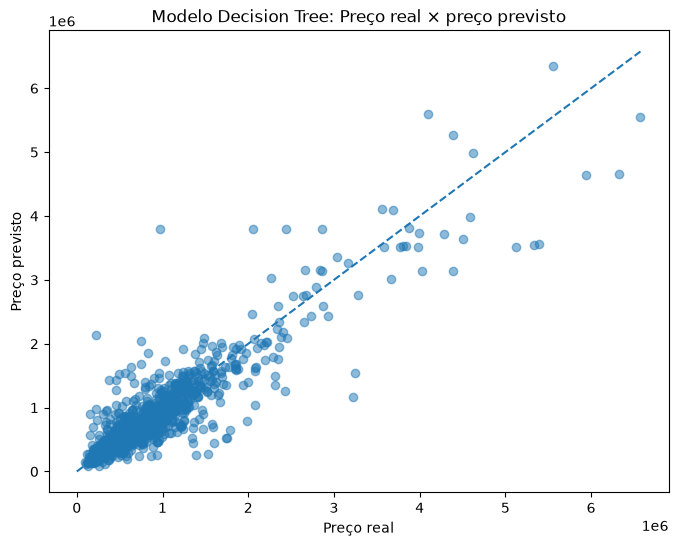

In [92]:
"""Grafico de dispersão entre o preço real e o preço previsto pelo modelo Decision Tree"""
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_arvore,
    alpha=0.5
)

limite = max(y_test.max(), y_pred_arvore.max())

plt.plot(
    [0, limite],
    [0, limite],
    linestyle="--"
)

plt.xlabel("Preço real")
plt.ylabel("Preço previsto")
plt.title("Modelo Decision Tree: Preço real × preço previsto")

plt.show()

In [93]:
erros = pd.DataFrame({
    "preco_real": y_test,
    "preco_previsto": y_pred_arvore
})

erros["erro"] = (
    erros["preco_real"] -
    erros["preco_previsto"]
)

erros["erro_absoluto"] = erros["erro"].abs()
print("10 maiores erros na Decision Tree:")
erros.sort_values(
    "erro_absoluto",
    ascending=False
).head(10)

10 maiores erros na Decision Tree:


,preco_real,preco_previsto,erro,erro_absoluto
5215,974255.0,3789445.0,-2815190.0,2815190.0
2698,3228079.0,1160115.0,2067964.0,2067964.0
5043,219599.0,2141309.0,-1921710.0,1921710.0
4713,5396180.0,3562977.0,1833203.0,1833203.0
2063,5334862.0,3549564.0,1785298.0,1785298.0
1501,2052439.0,3789445.0,-1737006.0,1737006.0
1882,3249378.0,1536792.0,1712586.0,1712586.0
3236,6329296.0,4661060.0,1668236.0,1668236.0
3157,5120781.0,3518360.0,1602421.0,1602421.0
5465,4092279.0,5593551.0,-1501272.0,1501272.0


**Modelo Random Forest**

In [94]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline # Garanta que o Pipeline esteja importado

modelo_rf = Pipeline(steps=[                    # definindo o pipeline random forest
    ("preprocessamento", preprocessamento),
    ("modelo", RandomForestRegressor(           
        n_estimators=200, # número de árvores na floresta
        max_depth=None,
        random_state=42,
        n_jobs=-1 # para utilizar todos os núcleos do processador
    ))                                          
])

y_pred_rf = modelo_rf.fit(X_train, y_train).predict(X_test)


In [95]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"R²: {r2_rf:.4f}")
print(f"MAE : R$ {mae_rf:,.2f}")
print(f"RMSE: R$ {rmse_rf:,.2f}")

R²: 0.8995
MAE : R$ 153,691.23
RMSE: R$ 252,716.68


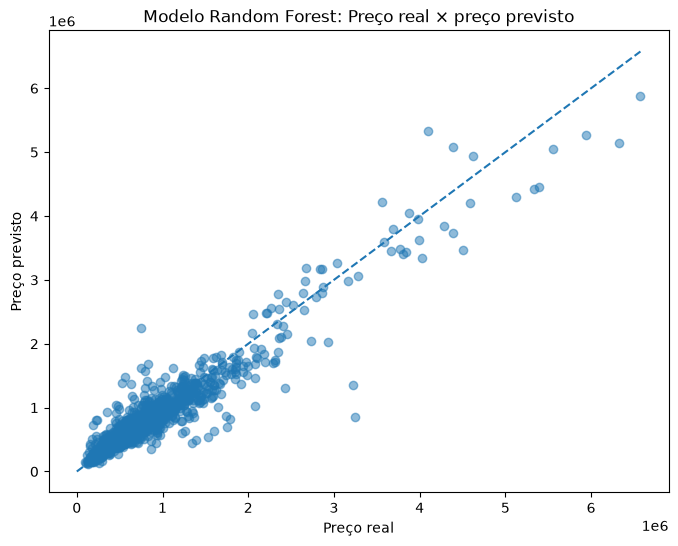

In [96]:
"""Grafico de dispersão entre o preço real e o preço previsto pelo modelo Random Forest"""
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.5
)

limite = max(y_test.max(), y_pred_rf.max())

plt.plot(
    [0, limite],
    [0, limite],
    linestyle="--"
)

plt.xlabel("Preço real")
plt.ylabel("Preço previsto")
plt.title("Modelo Random Forest: Preço real × preço previsto")

plt.show()

In [97]:
erros = pd.DataFrame({
    "preco_real": y_test,
    "preco_previsto": y_pred_rf
})

erros["erro"] = (
    erros["preco_real"] -
    erros["preco_previsto"]
)

erros["erro_absoluto"] = erros["erro"].abs()
print("10 maiores erros na Random Forest:")
erros.sort_values(
    "erro_absoluto",
    ascending=False
).head(10)

10 maiores erros na Random Forest:


,preco_real,preco_previsto,erro,erro_absoluto
1882,3249378.0,852747.670,2396630.330,2396630.330
2698,3228079.0,1360270.630,1867808.370,1867808.370
3083,751430.0,2248220.715,-1496790.715,1496790.715
5465,4092279.0,5331484.270,-1239205.270,1239205.270
3236,6329296.0,5142309.100,1186986.900,1186986.900
2254,2433136.0,1307333.385,1125802.615,1125802.615
243,1757216.0,695219.100,1061996.900,1061996.900
187,2082475.0,1028405.920,1054069.080,1054069.080
312,4500331.0,3466775.735,1033555.265,1033555.265
51,1527745.0,541495.405,986249.595,986249.595


**Comaprando Indicadores dos 3 Modelos**

In [98]:
# tabela de resultados dos modelos, comparando os 3 modelos, Regressão Linear, Decision Tree e Random Forest, com as métricas MAE, RMSE e R2.
comparativo_resultados = pd.DataFrame({
    "Modelo": ["Regressão linear", "Árvore de Decisão", "Random Forest"],
    "MAE": [mae_linear, mae_arvore, mae_rf],
    "RMSE": [rmse_linear, rmse_arvore, rmse_rf],
    "R2": [r2_linear, r2_arvore, r2_rf]
})
print("Comparativo de resultados dos modelos:")
display(comparativo_resultados)

Comparativo de resultados dos modelos:


,Modelo,MAE,RMSE,R2
0,Regressão linear,202419.530172,329888.564323,0.828785
1,Árvore de Decisão,198775.521739,338648.327131,0.819572
2,Random Forest,153691.229536,252716.681364,0.899521


**Conclusão**
Random Forest é o melhor *candidato* para o caso, pois os 3 indicadores desse modelo são melhores que os dos demais modelos

Validando: Regressão Linear...
Validando: Árvore de Decisão...
Validando: Random Forest...


,R² Treino (média),R² Validação (média),R² Validação (desvio),Gap R² (%),MAE Treino (média),MAE Validação (média),MAE Validação (desvio),Gap MAE (%),RMSE Treino (média),RMSE Validação (média),RMSE Validação (desvio),Gap RMSE (%)
Modelo,,,,,,,,,,,,
Regressão Linear,0.8365,0.8234,0.0210,1.5584,182664.2165,187875.4279,11380.8039,2.852900e+00,300666.1509,309912.5008,22220.8699,3.0753
Árvore de Decisão,1.0000,0.7794,0.0513,22.0638,19.1253,195196.3202,8973.6302,1.020520e+06,778.1268,344089.4325,35090.7914,44120.2287
Random Forest,0.9846,0.8856,0.0262,10.0568,53868.2588,146903.4349,4995.7726,1.727087e+02,92253.4320,247276.3077,18511.4439,168.0402


,Regressão Linear,Árvore de Decisão,Random Forest
Fold 1,0.7923,0.6961,0.8530
Fold 2,0.8330,0.8044,0.9113
Fold 3,0.8501,0.8355,0.8999
Fold 4,0.8064,0.7455,0.8547
Fold 5,0.8353,0.8153,0.9090


Random Forest > Regressão Linear em 5 de 5 folds


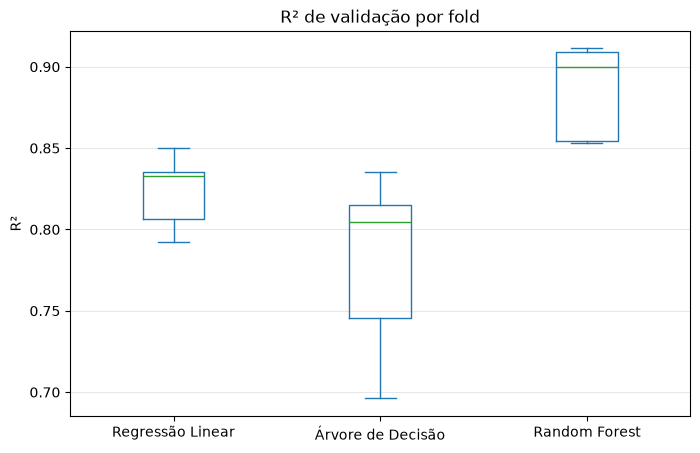

In [99]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_validate

# ------------------------------------------------------------------
# 1) Configuração
# ------------------------------------------------------------------
# A validação cruzada é feita SÓ no conjunto de treino.
# O X_test fica guardado, intocado, para a avaliação final.

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# O sklearn trabalha com "scores" (maior = melhor), por isso MAE e RMSE
# vêm negativos. Abaixo, invertemos o sinal para voltar a valores em R$.
scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
}

modelos = {
    "Regressão Linear": modelo_linear,
    "Árvore de Decisão": modelo_arvore,
    "Random Forest": modelo_rf,
}

# ------------------------------------------------------------------
# 2) Rodando a validação cruzada
# ------------------------------------------------------------------
# O cross_validate clona o pipeline a cada fold, então os modelos que
# você já treinou não são alterados. O pré-processamento (dentro do
# pipeline) é reajustado em cada fold, o que evita vazamento de dados.
# Obs.: o Random Forest treina 5 vezes, então pode demorar.

resultados = {}
for nome, modelo in modelos.items():
    print(f"Validando: {nome}...")
    resultados[nome] = cross_validate(
        modelo,
        X_train,
        y_train,
        cv=kf,
        scoring=scoring,
        return_train_score=True,
    )


def pegar(cv, fase, metrica):
    """Pega os valores de uma métrica (fase = 'train' ou 'test').
    Inverte o sinal de MAE e RMSE para voltarem a ser positivos."""
    valores = cv[f"{fase}_{metrica}"]
    return valores if metrica == "r2" else -valores


# ------------------------------------------------------------------
# 3) Tabela resumo: média, desvio padrão e gap
# ------------------------------------------------------------------
linhas = []
for nome, cv in resultados.items():
    linha = {"Modelo": nome}
    for metrica, rotulo in [("r2", "R²"), ("mae", "MAE"), ("rmse", "RMSE")]:
        val = pegar(cv, "test", metrica)    # "teste" de cada fold (validação)
        tre = pegar(cv, "train", metrica)

        linha[f"{rotulo} Treino (média)"] = tre.mean()
        linha[f"{rotulo} Validação (média)"] = val.mean()
        linha[f"{rotulo} Validação (desvio)"] = val.std()

        gap = (tre.mean() - val.mean()) if metrica == "r2" else (val.mean() - tre.mean())
        linha[f"Gap {rotulo} (%)"] = gap / tre.mean() * 100
    linhas.append(linha)

df_cv = pd.DataFrame(linhas).set_index("Modelo")
display(df_cv.round(4))

# ------------------------------------------------------------------
# 4) Resultado fold a fold (R²)
# ------------------------------------------------------------------
# Aqui dá para ver se um modelo ganha de forma CONSISTENTE.
df_folds = pd.DataFrame(
    {nome: pegar(cv, "test", "r2") for nome, cv in resultados.items()}
)
df_folds.index = [f"Fold {i + 1}" for i in range(kf.get_n_splits())]
display(df_folds.round(4))

# Em quantos folds o Random Forest superou a Regressão Linear?
vitorias = (df_folds["Random Forest"] > df_folds["Regressão Linear"]).sum()
print(f"Random Forest > Regressão Linear em {vitorias} de {len(df_folds)} folds")

# ------------------------------------------------------------------
# 5) Gráfico: distribuição do R² nos folds
# ------------------------------------------------------------------
df_folds.plot(kind="box", figsize=(8, 5))
plt.title("R² de validação por fold")
plt.ylabel("R²")
plt.grid(axis="y", alpha=0.3)
plt.show()